### Metadata Integration and Lineage Object Setup for Differential Abundance Analysis
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Metadata integration and lineage-specific object preparation*


#### Aim
This notebook prepares the full PICA cohort for downstream differential abundance analysis.

The annotated single-cell dataset is combined with donor-level metadata, including age, sex and batch information. Lineage-specific objects are then generated for CD4, CD8, NK and B-cell analyses.





In [1]:
import scanpy as sc
import anndata as ad
import scanpy.external as sce

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import scipy.sparse as sp

from rich import print
import warnings
warnings.filterwarnings("ignore")
import os

outdir = "/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007"
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = "/scratch/user/s4575250/BIOX7014_Thesis/figures/PICA/03_abundance_change"

## Load Annotated Adata
Load the full annotated PICA single-cell object containing cells from Batch001–Batch007.

In [ ]:
# load annotations
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad", backed="r")

adata.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm                 407516
CD8 naive/Tcm                 175694
CD56_dim CD16+ NK             171221
gdT                           136632
CD4 Tem                        96510
Naive B cell                   74528
Classical monocyte             51309
CD8 Tem                        50185
Tfh                            45002
CD8 GZMK+ naive/Tcm            39689
Treg                           39431
Switched memory B cell         39115
MAIT                           33604
Transitional B cell            20038
CX3CR1_high ncMonocyte         16593
ILC1                           16331
CD56_dim CD16+ KLRC2+ NK       15081
Intermediate monocyte          10877
CD4 cytoT                       8027
Platelet                        7029
Atypical memory B cell          5734
cDC2                            5434
pDC                             4415
Proliferating lymphocyte        2683
iILC2                           2400
DP T                            23

In [3]:
adata.obs["pica_id"].unique()
adata.obs['pica_id'].value_counts().sort_index()

pica_id
PICA0001     3992
PICA0002     3367
PICA0003     3357
PICA0004     3554
PICA0005     4943
            ...  
PICA0164    12172
PICA0166    12216
PICA0168    12590
PICA0169    12506
PICA0173    13800
Name: count, Length: 128, dtype: int64

In [4]:
print(adata)

AnnData object with n_obs × n_vars = 1485141 × 38606 backed at 
'/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad'
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

## Load metadata
Load the donor-level metadata file containing pica_id, batch, age, sex and sample information.

In [5]:
meta_raw = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA-PICAReportOverall_DATA_LABELS_2025-07-25_1224.csv")

In [ ]:
# convert Record ID in metadata -> PICA format (PICA0001)
meta = meta_raw.copy()
meta["Record ID"] = meta["Record ID"].astype(int)

meta["pica_id"] = meta["Record ID"].apply(lambda x: f"PICA{x:04d}")
meta.set_index("pica_id", inplace=True)

print(meta["Record ID"])

pica_id
PICA0001      1
PICA0002      2
PICA0003      3
PICA0004      4
PICA0005      5
           ... 
PICA0269    269
PICA0270    270
PICA0271    271
PICA0272    272
PICA0273    273
Name: Record ID, Length: 273, dtype: int64

In [ ]:
# restrict metadata to only those in present in adata
adata_picas = adata.obs["pica_id"].unique()
meta_sub = meta.loc[meta.index.isin(adata_picas)].copy()

print("Metadata before restricting:", meta.shape[0], "rows")
print("Metadata after restricting:", meta_sub.shape[0], "rows")

Metadata before restricting: 273 rows

Metadata after restricting: 128 rows

In [ ]:
# Map each metadata column from donor-level metadata to cell-level AnnData observations
adata.obs["pica_id"] = adata.obs["pica_id"].astype(str)
meta_sub.index = meta_sub.index.astype(str)

for col in meta_sub.columns:
    mapping = meta_sub[col]
    adata.obs[col] = adata.obs["pica_id"].map(mapping)

adata.obs[[ "pica_id", "Record ID" ]].head()  
print("n_obs:", adata.n_obs)
print("obs rows:", adata.obs.shape[0])

n_obs: 1485141

obs rows: 1485141

In [9]:
print(adata.obs.columns)


Index(['status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type',
       'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type',
       'pica_cell_type_01_myeloid', 'pica_cell_type_02_b',
       'pica_cell_type_03_nk_t', 'pica_cell_type_complete',
       'pica_broad_cell_type_complete',
       'pica_broad_cell_type_complete_01_gdT_corrected',
       'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica',
       'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name',
       'Was baseline blood sample collected?', 'IFC ID', 'Child's sex',
       'Age in years at the time of collection',
       'Age in months at the time of collection',
       '1) Does your child have any significant health issue or condition?',
       'Date and time of blood collection',
       '4) Does your child have any allergies diagnosed by a medical practitioner?',
       '5) Has your child shown any allergic symptoms within the last 2 months?',
       '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two 
weeks)?',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))',
       'My family member has a history of (specify family member)',
       'My child has a history of:  (Specify diagnosis date)',
       '8) Has your child ever been breastfed?',
       '9) What is your child's ethnicity? (choice=White Australian)',
       '9) What is your child's ethnicity? (choice=Australian Aboriginal)',
       '9) What is your child's ethnicity? (choice=Australian South Sea Islander)',
       '9) What is your child's ethnicity? (choice=Torres Strait Islander)',
       '9) What is your child's ethnicity? (choice=Māori)',
       '9) What is your child's ethnicity? (choice=New Zealander)',
       '9) What is your child's ethnicity? (choice=Pacific Islander)',
       '9) What is your child's ethnicity? (choice=North-West European)',
       '9) What is your child's ethnicity? (choice=Southern and Eastern European)',
       '9) What is your child's ethnicity? (choice=North African and Middle Eastern)',
       '9) What is your child's ethnicity? (choice=South-East Asian)',
       '9) What is your child's ethnicity? (choice=North-East Asian)',
       '9) What is your child's ethnicity? (choice=Southern and Central Asian)',
       '9) What is your child's ethnicity? (choice=Latin American and Caribbean)',
       '9) What is your child's ethnicity? (choice=Sub-Saharan African)',
       '9) What is your child's ethnicity? (choice=Decline to answer)',
       '9) What is your child's ethnicity? (choice=Other, please specify:)',
       'Specify ethnicity'],
      dtype='object')

In [ ]:
# Generate a donor-level summary to confirm age and sex metadata mapping
meta_summary = (
    adata.obs[["pica_id", "Child's sex", "Age in years at the time of collection"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary)

pica_id Child's sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0001        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0002        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0003        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0004        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0005        Male   
...                                                      ...         ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0164        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0166        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0168        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0169        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0173        Male   

                                                    Age in years at the time of collection  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    2.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                   15.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    0.83  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    3.46  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    9.30  
...                                                                                    ...  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    2.15  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    0.62  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                   16.20  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    2.72  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                   15.31  

[128 rows x 3 columns]

In [ ]:
# Rename covariates
adata.obs['Batch'] = adata.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata.obs = adata.obs.rename(columns={
    "Age (years)": "Age_years"
})

In [ ]:
# Confirm final donor-level covariates used for downstream analyses
meta_summary_renamed = (
    adata.obs[["Batch","pica_id", "Sex", "Age_years"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary_renamed)

Batch   pica_id   Sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0001  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0002  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0003  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0004  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0005  Male   
...                                                     ...       ...   ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0164  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0166  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0168  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0169  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0173  Male   

                                                    Age_years  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...       2.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...      15.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...       0.83  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...       1.46  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...       9.30  
...                                                       ...  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...       2.15  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...       0.62  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...      16.20  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...       2.72  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...      15.31  

[128 rows x 4 columns]

# Visualise Donor Sex and Age Distribution

Summarise cohort structure to confirm that age and sex covariates are available for downstream models.

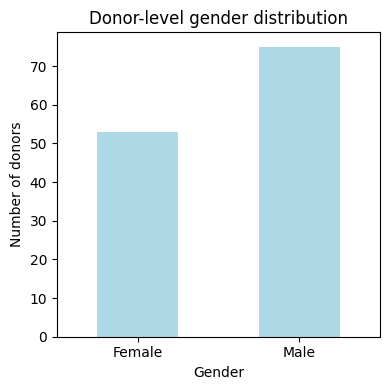

In [ ]:
# Plot donor-level sex distribution to assess cohort balance
gender_meta_df = adata.obs[["pica_id", "Sex"]].drop_duplicates()

gender_meta_df["Sex"].value_counts().sort_index().plot(
    kind="bar", color="lightblue", figsize=(4,4)
)
plt.title("Donor-level gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

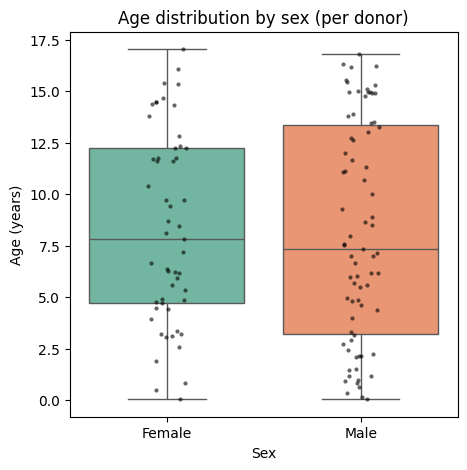

In [ ]:
# Plot donor-level age distribution by sex
meta_df = adata.obs[['pica_id', "Sex", "Age_years"]].drop_duplicates()

plt.figure(figsize=(5,5))
sns.boxplot(data=meta_df, x="Sex", y="Age_years", palette="Set2")
sns.stripplot(data=meta_df, x="Sex", y="Age_years", color="k", size=3, alpha=0.6)
plt.title("Age distribution by sex (per donor)")
plt.ylabel("Age (years)")
plt.xlabel("Sex")
plt.show()

In [ ]:
# clean metadata types for downstream analysis
adata.obs = adata.obs.applymap(
    lambda x: str(x) if not isinstance(x, (int, float, str)) else x
)

In [16]:
adata

AnnData object with n_obs × n_vars = 1485141 × 38606 backed at '/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad'
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_year

___

## Clean up age and define Age Groups

Create age groups for visualisation and descriptive summaries while retaining continuous age for statistical modelling.

In [ ]:
adata.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [18]:
adata.obs.groupby("pica_id")["Age"].unique()

pica_id
PICA0001     [2]
PICA0002    [15]
PICA0003     [0]
PICA0004     [1]
PICA0005     [9]
            ... 
PICA0164     [2]
PICA0166     [0]
PICA0168    [16]
PICA0169     [2]
PICA0173    [15]
Name: Age, Length: 128, dtype: object

In [ ]:
# Define bins and labels
bins = [0, 3, 6, 10, 14, 18]
labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

# Create categorical age group variable
adata.obs["Age_group"] = pd.cut(
    adata.obs["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

In [ ]:
# Cell count by integer age
adata.obs["Age"].value_counts().sort_index()

Age
0     104303
1      53227
2      87995
3      91224
4     151808
5      80498
6     120162
7      92155
8      69967
9      43193
10     35359
11    121864
12     71899
13     91584
14    130672
15     68505
16     56628
17     14098
Name: count, dtype: int64

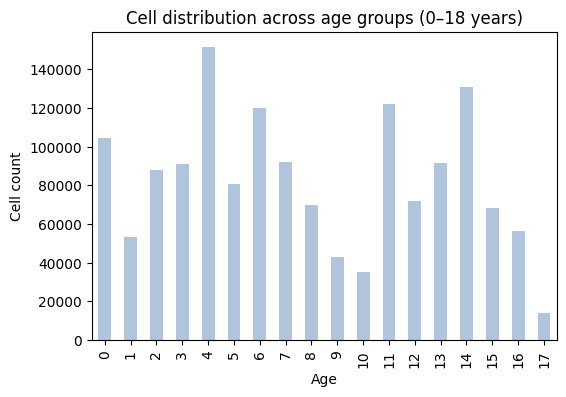

In [ ]:
# Plot cell-level age distribution
adata.obs["Age"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age")
plt.ylabel("Cell count")
plt.show()

In [ ]:
# Cell count by age group
adata.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      336749
4–6      352468
7–10     240674
11–14    416019
15–18    139231
Name: count, dtype: int64

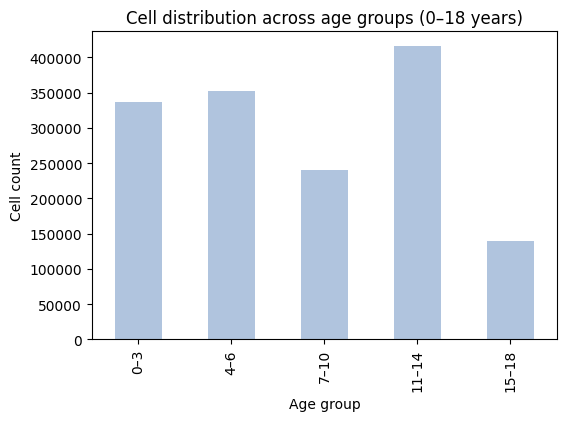

In [ ]:
# Plot cell-level age group distribution
adata.obs["Age_group"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age group")
plt.ylabel("Cell count")
plt.show()

In [ ]:
# create donor-level age group summary
age_meta_df = adata.obs[["pica_id", "Age"]].drop_duplicates()

# Reindex ages from 0 to 18 so missing ages are shown explicitly as zero
age_order = list(range(0, 19))
age_counts = (
    age_meta_df["Age"]
    .value_counts()
    .reindex(age_order, fill_value=0)
)

age_counts

Age
0     10
1      5
2      8
3      8
4     12
5      7
6     10
7      8
8      6
9      4
10     3
11    10
12     6
13     7
14    11
15     7
16     5
17     1
18     0
Name: count, dtype: int64

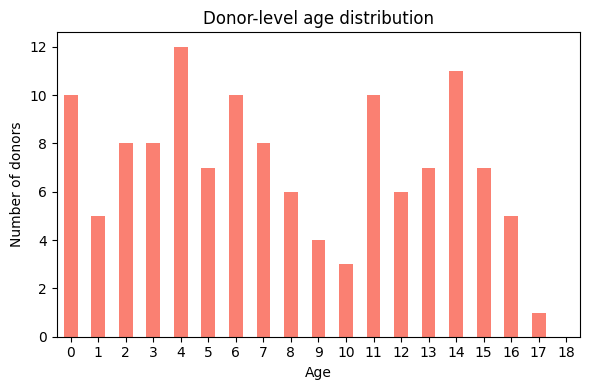

In [ ]:
# Plot donor-level age distribution
age_counts.plot(
    kind="bar",
    color="salmon",
    figsize=(6, 4)
)
plt.title("Donor-level age distribution")
plt.xlabel("Age")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# create donor-level age group summary by age group
age_grp_meta_df = adata.obs[["pica_id", "Age_group"]].drop_duplicates()
age_grp_meta_df["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

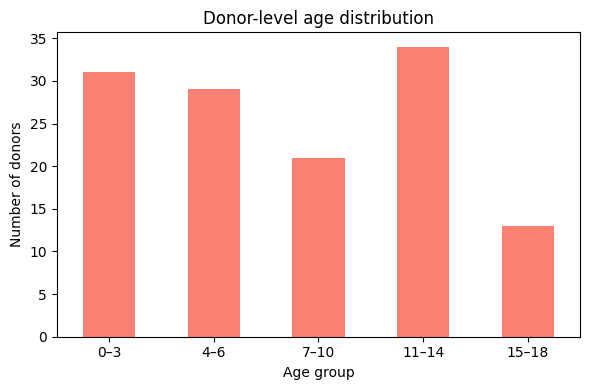

In [ ]:
# Plot donor-level age group distribution
age_grp_meta_df["Age_group"].value_counts().sort_index().plot(
    kind="bar", color="salmon", figsize=(6,4)
)
plt.title("Donor-level age distribution")
plt.xlabel("Age group")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
adata

AnnData object with n_obs × n_vars = 1485141 × 38606 backed at '/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad'
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_year

In [29]:
adata.obs.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_combined_annot_with_age_obs.csv")

___

## Define Major Immune Lineages

Group fine annotations into broader immune lineages for lineage-specific downstream analysis.

In [20]:
adata_subsets = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad",backed='r')
obs_new = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_combined_annot_with_age_obs.csv", index_col=0)
adata_subsets.obs = obs_new

In [21]:
adata_subsets

AnnData object with n_obs × n_vars = 1485141 × 38606 backed at '/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad'
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_year

In [22]:
cd4_cells = [
    "CD4 naive/Tcm", "CD4 Tem", "Tfh", "Treg", "CD4 cytoT",
]

cd8_cells = [
    "CD8 naive/Tcm", "CD8 GZMK+ naive/Tcm", "CD8 Tem", 
]

other_t_cells = [
    "gdT", "MAIT", "DN T", "DP T", "NKT", 'Proliferating lymphocyte',
]

nk_cells = [
    "CD56_dim CD16+ NK", "CD56_dim CD16+ KLRC2+ NK", "CD56_bright CD16- NK",
]

b_cells = [
    "Naive B cell", "Switched memory B cell", "Transitional B cell", "Atypical memory B cell", "Plasma cell"
]


In [23]:
adata_subsets.shape

(1485141, 38606)

In [24]:
adata_subsets.X.dtype

dtype('<f4')

In [25]:
obs = adata_subsets.obs.copy()

In [ ]:
# Assign broad lineage labels based on fine cell-type annotation
col = "pica_cell_type_complete_01_gdT_corrected"

obs["major_lineage"] = "Other"

# assign each group
obs.loc[obs[col].isin(cd4_cells), "major_lineage"] = "CD4"
obs.loc[obs[col].isin(cd8_cells), "major_lineage"] = "CD8"
obs.loc[obs[col].isin(nk_cells),  "major_lineage"] = "NK"
obs.loc[obs[col].isin(other_t_cells), "major_lineage"] = "Other_T"
obs.loc[obs[col].isin(b_cells),  "major_lineage"] = "B"

In [27]:
print(obs["major_lineage"].head())

20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAAAGCGT    CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAACGGCA     NK
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACAATAG    CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACTTACG    CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGATGGCGA     NK
Name: major_lineage, dtype: object

<Axes: xlabel='major_lineage'>

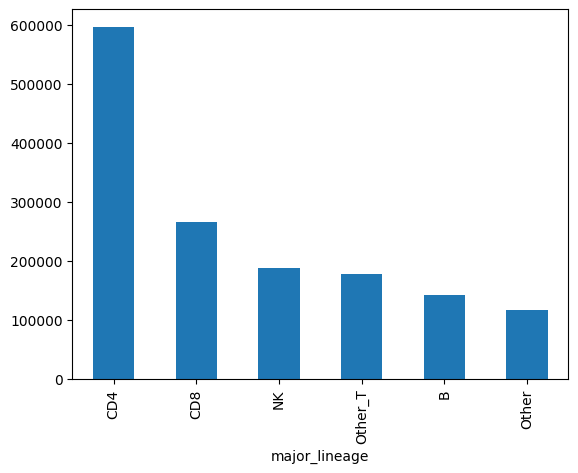

In [ ]:
# cell counts by major lineage to check expected composition
obs["major_lineage"].value_counts().plot(kind="bar")

In [ ]:
# Percentage contribution of each major lineage
(obs["major_lineage"].value_counts(normalize=True) * 100).round(2)

major_lineage
CD4        40.16
CD8        17.88
NK         12.60
Other_T    11.95
B           9.52
Other       7.88
Name: proportion, dtype: float64

In [30]:
# Summarise major lineages across age groups using raw cell counts
pd.crosstab(obs["major_lineage"], obs["Age_group"])


Age_group,0–3,11–14,15–18,4–6,7–10
major_lineage,,,,,
B,41025,34621,11811,33643,20351
CD4,151860,162356,55811,134748,91711
CD8,58370,72625,25907,64945,43721
NK,38395,50273,16840,47808,33857
Other,19286,40391,12696,25378,19289
Other_T,27813,55753,16166,45946,31745


In [ ]:
# Summarise major lineages across age groups as within-lineage proportions
pd.crosstab(obs["major_lineage"], obs["Age_group"], normalize="index").round(3)


Age_group,0–3,11–14,15–18,4–6,7–10
major_lineage,,,,,
B,0.290,0.245,0.083,0.238,0.144
CD4,0.255,0.272,0.094,0.226,0.154
CD8,0.220,0.273,0.098,0.245,0.165
NK,0.205,0.269,0.090,0.255,0.181
Other,0.165,0.345,0.108,0.217,0.165
Other_T,0.157,0.314,0.091,0.259,0.179


___

## Subset and Save CD4 Object

Extract CD4 T cells and save a lineage-specific object for downstream scCODA, Milo and expression analyses.


In [ ]:
# Identify cells assigned to the CD4 lineage
cd4_mask = obs["major_lineage"] == "CD4"
cd4_mask.sum()

np.int64(596486)

In [ ]:
# Convert CD4 mask into positional indices for subsetting the backed AnnData object
cd4_idx = np.where(cd4_mask)[0]
len(cd4_idx)

596486

In [ ]:
# Load CD4 subset into memory
adata_cd4 = adata_subsets[cd4_idx, :].to_memory()
print(adata_cd4.shape) 

(596486, 38606)

In [ ]:
# Check fine CD4 annotations retained in the subset
adata_cd4.obs["pica_cell_type_complete_01_gdT_corrected"].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm    407516
CD4 Tem           96510
Tfh               45002
Treg              39431
CD4 cytoT          8027
Name: count, dtype: int64

In [53]:
print(adata_cd4)

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [54]:
adata_cd4.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [ ]:
# Remove large object from memory before generating additional subsets
del adata_cd4

## Subset and Save CD8 Object

In [37]:
# Identify cells assigned to the CD8 lineage
cd8_mask = obs["major_lineage"] == "CD8"
cd8_mask.sum()

np.int64(265568)

In [ ]:
# Convert CD8 mask into positional indices
cd8_idx = np.where(cd8_mask)[0]
len(cd8_idx)

265568

In [ ]:
# Load CD8 subset into memory
adata_cd8 = adata_subsets[cd8_idx, :].to_memory()
print(adata_cd8.shape) 

(265568, 38606)

In [ ]:
# Check fine CD8 annotations retained in the subset
adata_cd8.obs["pica_cell_type_complete_01_gdT_corrected"].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD8 naive/Tcm          175694
CD8 Tem                 50185
CD8 GZMK+ naive/Tcm     39689
Name: count, dtype: int64

In [59]:
print(adata_cd8)

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [60]:
adata_cd8.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [41]:
del adata_cd8

## Subset and save NK object

In [42]:
# NK
nk_mask = obs["major_lineage"] == "NK"
nk_mask.sum()

np.int64(187173)

In [43]:
nk_idx = np.where(nk_mask)[0]
len(nk_idx)

187173

In [44]:
adata_nk = adata_subsets[nk_idx, :].to_memory()
print(adata_nk.shape) 

(187173, 38606)

In [45]:
adata_nk.obs["pica_cell_type_complete_01_gdT_corrected"].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
CD56_dim CD16+ KLRC2+ NK     15081
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [65]:
print(adata_nk)

AnnData object with n_obs × n_vars = 187173 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [66]:
adata_nk.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [46]:
del adata_nk

# Subset and save B cell object
Extract B cells for exploratory analyses related to humoral immune composition.

In [47]:
# B
b_mask = obs["major_lineage"] == "B"
b_mask.sum()

np.int64(141451)

In [48]:
b_idx = np.where(b_mask)[0]
len(b_idx)

141451

In [49]:
adata_b = adata_subsets[b_idx, :].to_memory()
print(adata_b.shape) 

(141451, 38606)

In [50]:
adata_b.obs["pica_cell_type_complete_01_gdT_corrected"].value_counts()

pica_cell_type_complete_01_gdT_corrected
Naive B cell              74528
Switched memory B cell    39115
Transitional B cell       20038
Atypical memory B cell     5734
Plasma cell                2036
Name: count, dtype: int64

In [51]:
print(adata_b)

AnnData object with n_obs × n_vars = 141451 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [52]:
adata_b.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_b_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [53]:
del adata_b